In [ ]:
import pandas as pd
from pathlib import Path

data_path = Path("Data/European_data_2000.csv")
df = pd.read_csv(data_path)

In [ ]:
preview_cols = [
    "titleId",
    "originalTitle",
    "releaseYear",
    "runtimeMinutes",
    "imdbRating",
    "numberOfVotes",
    "mainCountry",
    "genres",
]
available_preview_cols = [col for col in preview_cols if col in df.columns]

print(f"Loaded: {data_path}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

if "mainCountry" in df.columns:
    print("\nTop 10 main countries:")
    print(df["mainCountry"].value_counts().head(10))

print("\nFirst 5 rows:")
display(df[available_preview_cols].head())

print("\nNumeric summary:")
display(df.describe(include="number"))

Loaded: Data/European_data_2000.csv
Shape: 2000 rows x 23 columns

Columns:
['titleId', 'imdbUrl', 'originalTitle', 'titleType', 'releaseYear', 'runtimeMinutes', 'isAdult', 'imdbRating', 'numberOfVotes', 'allCountries', 'mainCountry', 'allLanguages', 'firstLanguage', 'englishTitle', 'topFiveActors', 'directors', 'writers', 'plotShort', 'plotMedium', 'plotLong', 'genres', 'keywords', 'production']

Data types:
titleId            object
imdbUrl            object
originalTitle      object
titleType          object
releaseYear       float64
runtimeMinutes    float64
isAdult              bool
imdbRating        float64
numberOfVotes     float64
allCountries       object
mainCountry        object
allLanguages       object
firstLanguage      object
englishTitle       object
topFiveActors      object
directors          object
writers            object
plotShort          object
plotMedium         object
plotLong           object
genres             object
keywords           object
production     

,titleId,originalTitle,releaseYear,runtimeMinutes,imdbRating,numberOfVotes,mainCountry,genres
0,tt3042384,Ida,2013.0,82.0,7.4,61189.0,PL,Drama
1,tt2486278,Blood Shed,2013.0,99.0,3.1,689.0,GB,"Horror, Thriller"
2,tt1361313,The Extra Man,2010.0,108.0,5.8,5470.0,FR,Comedy
3,tt0222124,Se tutte le donne del mondo... (Operazione Par...,1966.0,106.0,6.0,434.0,IT,"Action, Comedy"
4,tt0421229,Mrs Palfrey at the Claremont,2005.0,108.0,7.6,4382.0,GB,"Comedy, Drama"



Numeric summary:


,releaseYear,runtimeMinutes,imdbRating,numberOfVotes
count,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,1997.515500,104.324500,6.386400,5.385845e+04
std,21.796979,20.470777,1.069606,1.284624e+05
min,1913.000000,45.000000,1.500000,1.000000e+01
25%,1981.000000,91.000000,5.800000,2.815250e+03
50%,2006.000000,100.000000,6.500000,1.176900e+04
75%,2014.000000,114.000000,7.100000,4.882325e+04
max,2024.000000,317.000000,9.100000,2.407126e+06


## Data Quality

In [4]:
dq = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "null_pct": (df.isna().mean() * 100).round(2).values,
    "n_unique": df.nunique(dropna=True).values,
})

print("Column quality summary:")
display(dq)

print("Top 15 columns by null_pct:")
display(dq.sort_values(["null_pct", "column"], ascending=[False, True]).head(15).reset_index(drop=True))

dup_key_cols = []
dup_key_label = ""
if "titleId" in df.columns:
    dup_key_cols = ["titleId"]
    dup_key_label = "titleId"
elif {"originalTitle", "releaseYear"}.issubset(df.columns):
    dup_key_cols = ["originalTitle", "releaseYear"]
    dup_key_label = "(originalTitle, releaseYear)"

if dup_key_cols:
    dup_mask = df.duplicated(subset=dup_key_cols, keep=False)
    dup_rows = df.loc[dup_mask]
    dup_groups = (
        dup_rows.groupby(dup_key_cols, dropna=False)
        .size()
        .rename("rows_in_group")
        .reset_index()
        .sort_values("rows_in_group", ascending=False)
    )
    print(f"Duplicate rows by {dup_key_label}: {int(dup_mask.sum())}")
    print(f"Duplicate groups by {dup_key_label}: {len(dup_groups)}")
    print("First 10 duplicate groups:")
    display(dup_groups.head(10).reset_index(drop=True))
else:
    print("Duplicate check skipped: neither titleId nor (originalTitle, releaseYear) columns are available.")

Column quality summary:


,column,dtype,non_null,null_pct,n_unique
0,titleId,object,2000,0.0,2000
1,imdbUrl,object,2000,0.0,2000
2,originalTitle,object,2000,0.0,1867
3,titleType,object,2000,0.0,1
4,releaseYear,float64,2000,0.0,101
5,runtimeMinutes,float64,2000,0.0,122
6,isAdult,bool,2000,0.0,2
7,imdbRating,float64,2000,0.0,68
8,numberOfVotes,float64,2000,0.0,1912
9,allCountries,object,2000,0.0,539


Top 15 columns by null_pct:


,column,dtype,non_null,null_pct,n_unique
0,allCountries,object,2000,0.0,539
1,allLanguages,object,2000,0.0,439
2,directors,object,2000,0.0,1354
3,englishTitle,object,2000,0.0,1868
4,firstLanguage,object,2000,0.0,45
5,genres,object,2000,0.0,564
6,imdbRating,float64,2000,0.0,68
7,imdbUrl,object,2000,0.0,2000
8,isAdult,bool,2000,0.0,2
9,keywords,object,2000,0.0,1905


Duplicate rows by titleId: 0
Duplicate groups by titleId: 0
First 10 duplicate groups:


,titleId,rows_in_group


## Type Fixes & Validity Flags

In [5]:
coerce_cols = ["releaseYear", "runtimeMinutes", "imdbRating", "numberOfVotes"]
for col in coerce_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "releaseYear" in df.columns:
    df["bad_releaseYear"] = df["releaseYear"].isna() | ~df["releaseYear"].between(1880, 2027)
else:
    df["bad_releaseYear"] = True

if "runtimeMinutes" in df.columns:
    df["bad_runtime"] = df["runtimeMinutes"].isna() | (df["runtimeMinutes"] <= 0) | (df["runtimeMinutes"] > 400)
else:
    df["bad_runtime"] = True

if "imdbRating" in df.columns:
    df["bad_rating"] = df["imdbRating"].isna() | ~df["imdbRating"].between(0, 10)
else:
    df["bad_rating"] = True

if "numberOfVotes" in df.columns:
    df["bad_votes"] = df["numberOfVotes"].isna() | (df["numberOfVotes"] < 0)
else:
    df["bad_votes"] = True

flag_cols = ["bad_releaseYear", "bad_runtime", "bad_rating", "bad_votes"]
flag_summary = pd.DataFrame({
    "flag": flag_cols,
    "count": [int(df[col].sum()) for col in flag_cols],
})
flag_summary["pct"] = (flag_summary["count"] / len(df) * 100).round(2)

print("Validity flag summary:")
display(flag_summary)

row_has_bad = df[flag_cols].any(axis=1)
print(f"Rows with any bad_* flag: {int(row_has_bad.sum())}")

base_cols = ["titleId", "originalTitle", "releaseYear", "runtimeMinutes", "imdbRating", "numberOfVotes"]
show_cols = [col for col in base_cols if col in df.columns] + flag_cols
display(df.loc[row_has_bad, show_cols].head(20))

Validity flag summary:


,flag,count,pct
0,bad_releaseYear,0,0.0
1,bad_runtime,0,0.0
2,bad_rating,0,0.0
3,bad_votes,0,0.0


Rows with any bad_* flag: 0


,titleId,originalTitle,releaseYear,runtimeMinutes,imdbRating,numberOfVotes,bad_releaseYear,bad_runtime,bad_rating,bad_votes


## Univariate Distributions

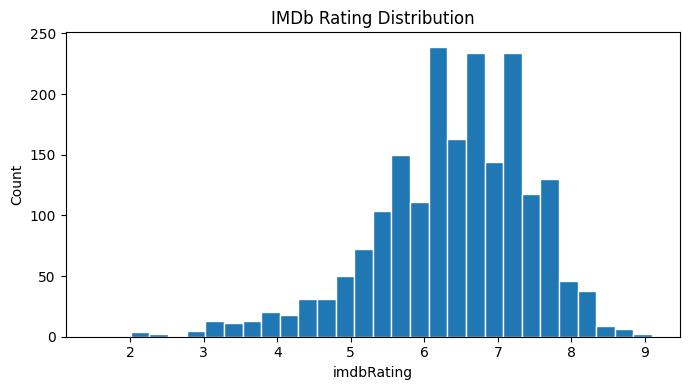

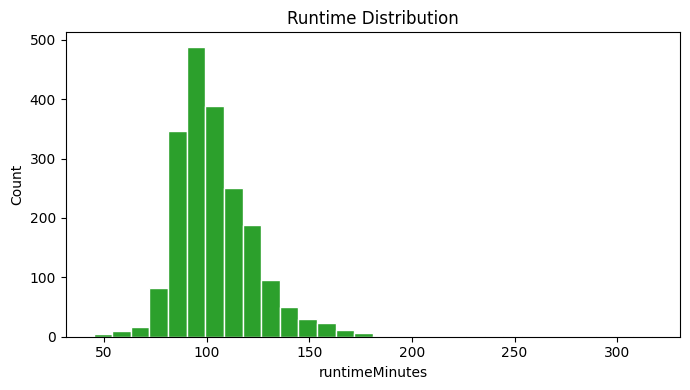

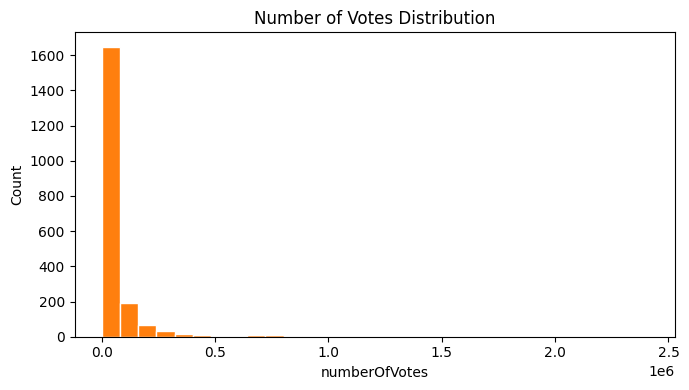

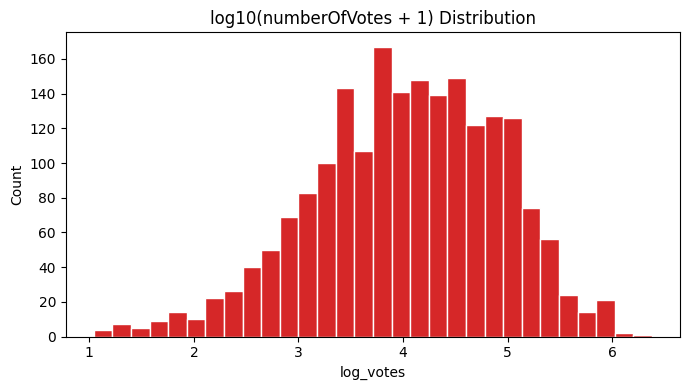

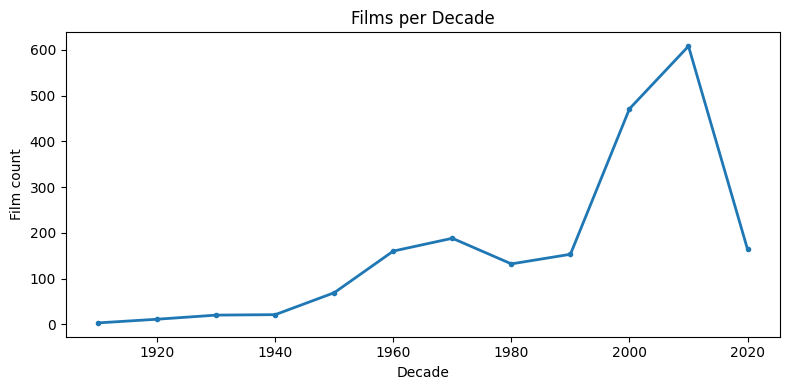

Saved figures to: /Users/andreas/Will-Agency-42576-From-analytics-to-action-/outputs/figures


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path("outputs/figures")
out_dir.mkdir(parents=True, exist_ok=True)

if "imdbRating" in df.columns:
    s = pd.to_numeric(df["imdbRating"], errors="coerce").dropna()
    if len(s) > 0:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(s, bins=30, color="#1f77b4", edgecolor="white")
        ax.set_title("IMDb Rating Distribution")
        ax.set_xlabel("imdbRating")
        ax.set_ylabel("Count")
        fig.tight_layout()
        fig.savefig(out_dir / "hist_imdbRating.png", dpi=150)
        plt.show()
        plt.close(fig)

if "runtimeMinutes" in df.columns:
    s = pd.to_numeric(df["runtimeMinutes"], errors="coerce").dropna()
    if len(s) > 0:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(s, bins=30, color="#2ca02c", edgecolor="white")
        ax.set_title("Runtime Distribution")
        ax.set_xlabel("runtimeMinutes")
        ax.set_ylabel("Count")
        fig.tight_layout()
        fig.savefig(out_dir / "hist_runtimeMinutes.png", dpi=150)
        plt.show()
        plt.close(fig)

if "numberOfVotes" in df.columns:
    votes = pd.to_numeric(df["numberOfVotes"], errors="coerce")
    s = votes.dropna()
    if len(s) > 0:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(s, bins=30, color="#ff7f0e", edgecolor="white")
        ax.set_title("Number of Votes Distribution")
        ax.set_xlabel("numberOfVotes")
        ax.set_ylabel("Count")
        fig.tight_layout()
        fig.savefig(out_dir / "hist_numberOfVotes.png", dpi=150)
        plt.show()
        plt.close(fig)

    df["log_votes"] = np.log10(votes.clip(lower=0) + 1)
    log_s = df["log_votes"].dropna()
    if len(log_s) > 0:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(log_s, bins=30, color="#d62728", edgecolor="white")
        ax.set_title("log10(numberOfVotes + 1) Distribution")
        ax.set_xlabel("log_votes")
        ax.set_ylabel("Count")
        fig.tight_layout()
        fig.savefig(out_dir / "hist_log10_numberOfVotes_plus1.png", dpi=150)
        plt.show()
        plt.close(fig)

if "releaseYear" in df.columns:
    years = pd.to_numeric(df["releaseYear"], errors="coerce").dropna().round().astype(int)
    if len(years) > 0:
        if years.nunique() > 60:
            x = (years // 10) * 10
            counts = x.value_counts().sort_index()
            x_label = "Decade"
            title = "Films per Decade"
            year_path = out_dir / "films_per_decade.png"
        else:
            counts = years.value_counts().sort_index()
            x_label = "releaseYear"
            title = "Films per Release Year"
            year_path = out_dir / "films_per_releaseYear.png"

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(counts.index, counts.values, linewidth=2, marker="o", markersize=3)
        ax.set_title(title)
        ax.set_xlabel(x_label)
        ax.set_ylabel("Film count")
        fig.tight_layout()
        fig.savefig(year_path, dpi=150)
        plt.show()
        plt.close(fig)

print(f"Saved figures to: {out_dir.resolve()}")

## Bivariate Relationships

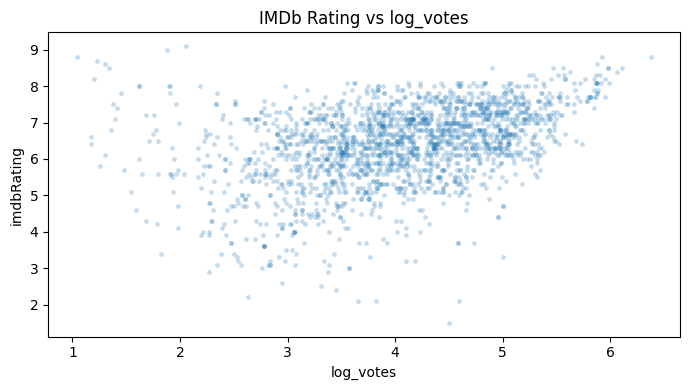

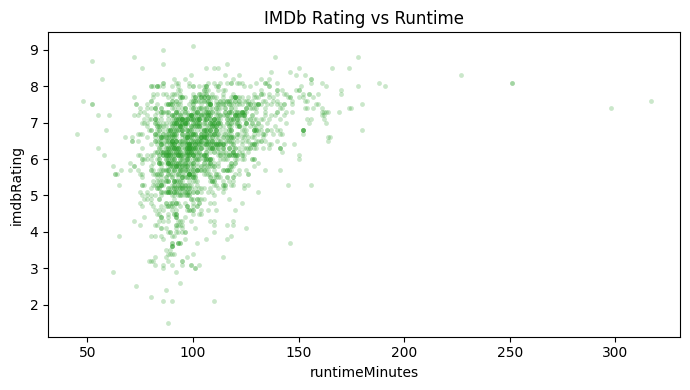

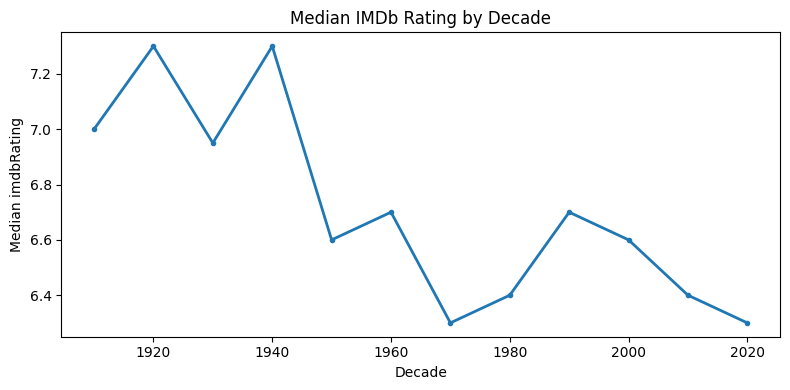

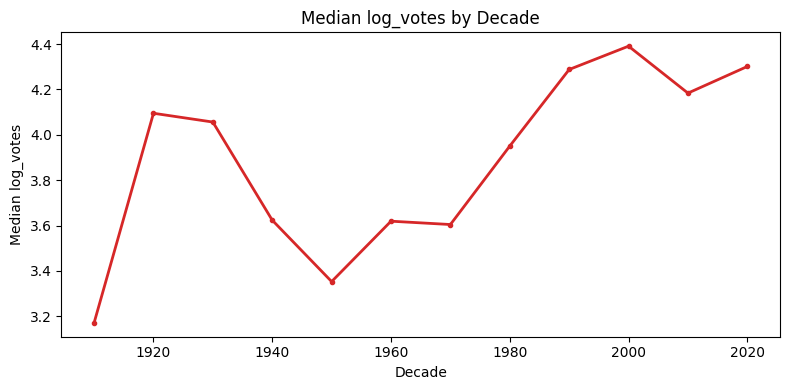

Numeric correlation table:


,releaseYear,runtimeMinutes,imdbRating,numberOfVotes,log_votes
releaseYear,1.000000,0.095829,-0.116751,0.107621,0.188303
runtimeMinutes,0.095829,1.000000,0.339459,0.280007,0.379877
imdbRating,-0.116751,0.339459,1.000000,0.330063,0.391583
numberOfVotes,0.107621,0.280007,0.330063,1.000000,0.576666
log_votes,0.188303,0.379877,0.391583,0.576666,1.000000


Saved figures to: /Users/andreas/Will-Agency-42576-From-analytics-to-action-/outputs/figures


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path("outputs/figures")
out_dir.mkdir(parents=True, exist_ok=True)

if "log_votes" not in df.columns and "numberOfVotes" in df.columns:
    votes = pd.to_numeric(df["numberOfVotes"], errors="coerce")
    df["log_votes"] = np.log10(votes.clip(lower=0) + 1)

if {"imdbRating", "log_votes"}.issubset(df.columns):
    plot_df = df[["imdbRating", "log_votes"]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(plot_df) > 0:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.scatter(plot_df["log_votes"], plot_df["imdbRating"], alpha=0.25, s=12, linewidths=0)
        ax.set_title("IMDb Rating vs log_votes")
        ax.set_xlabel("log_votes")
        ax.set_ylabel("imdbRating")
        fig.tight_layout()
        fig.savefig(out_dir / "scatter_imdbRating_vs_log_votes.png", dpi=150)
        plt.show()
        plt.close(fig)

if {"imdbRating", "runtimeMinutes"}.issubset(df.columns):
    plot_df = df[["imdbRating", "runtimeMinutes"]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(plot_df) > 0:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.scatter(plot_df["runtimeMinutes"], plot_df["imdbRating"], alpha=0.25, s=12, linewidths=0, color="#2ca02c")
        ax.set_title("IMDb Rating vs Runtime")
        ax.set_xlabel("runtimeMinutes")
        ax.set_ylabel("imdbRating")
        fig.tight_layout()
        fig.savefig(out_dir / "scatter_imdbRating_vs_runtimeMinutes.png", dpi=150)
        plt.show()
        plt.close(fig)

if {"releaseYear", "imdbRating"}.issubset(df.columns):
    trend_df = df[["releaseYear", "imdbRating"]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(trend_df) > 0:
        trend_df["releaseYear"] = trend_df["releaseYear"].round().astype(int)
        if trend_df["releaseYear"].nunique() > 60:
            trend_df["period"] = (trend_df["releaseYear"] // 10) * 10
            x_label = "Decade"
            title = "Median IMDb Rating by Decade"
            path = out_dir / "median_imdbRating_by_decade.png"
        else:
            trend_df["period"] = trend_df["releaseYear"]
            x_label = "releaseYear"
            title = "Median IMDb Rating by Release Year"
            path = out_dir / "median_imdbRating_by_releaseYear.png"

        series = trend_df.groupby("period")["imdbRating"].median().sort_index()
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(series.index, series.values, linewidth=2, marker="o", markersize=3)
        ax.set_title(title)
        ax.set_xlabel(x_label)
        ax.set_ylabel("Median imdbRating")
        fig.tight_layout()
        fig.savefig(path, dpi=150)
        plt.show()
        plt.close(fig)

if {"releaseYear", "log_votes"}.issubset(df.columns):
    trend_df = df[["releaseYear", "log_votes"]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(trend_df) > 0:
        trend_df["releaseYear"] = trend_df["releaseYear"].round().astype(int)
        if trend_df["releaseYear"].nunique() > 60:
            trend_df["period"] = (trend_df["releaseYear"] // 10) * 10
            x_label = "Decade"
            title = "Median log_votes by Decade"
            path = out_dir / "median_log_votes_by_decade.png"
        else:
            trend_df["period"] = trend_df["releaseYear"]
            x_label = "releaseYear"
            title = "Median log_votes by Release Year"
            path = out_dir / "median_log_votes_by_releaseYear.png"

        series = trend_df.groupby("period")["log_votes"].median().sort_index()
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(series.index, series.values, linewidth=2, marker="o", markersize=3, color="#d62728")
        ax.set_title(title)
        ax.set_xlabel(x_label)
        ax.set_ylabel("Median log_votes")
        fig.tight_layout()
        fig.savefig(path, dpi=150)
        plt.show()
        plt.close(fig)

corr_tbl = df.select_dtypes(include="number").corr()
print("Numeric correlation table:")
display(corr_tbl)

print(f"Saved figures to: {out_dir.resolve()}")

## Country Analysis

country_stats (top 20 by n_films):


,mainCountry,n_films,median_rating,median_votes,share_missing_rating
0,GB,981,6.50,14234.0,0.0
1,FR,265,6.70,13764.0,0.0
2,IT,167,6.30,3771.0,0.0
3,DE,163,6.40,33352.0,0.0
4,ES,92,6.15,9280.0,0.0
5,IE,65,6.50,19004.0,0.0
6,SE,36,6.70,9879.0,0.0
7,DK,34,6.80,16229.5,0.0
8,GR,22,7.00,3082.0,0.0
9,CZ,21,6.60,3933.0,0.0


Countries meeting threshold n_films >= 30: 8


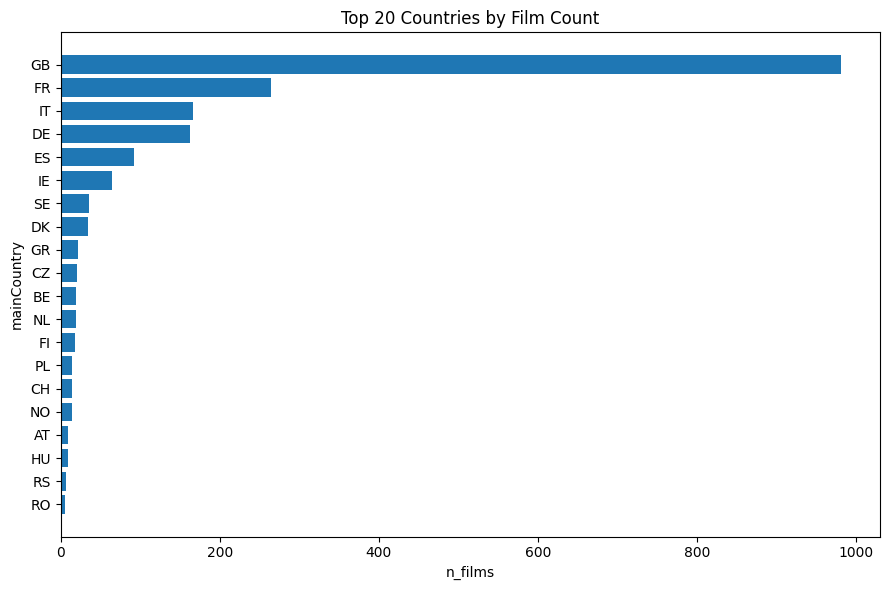

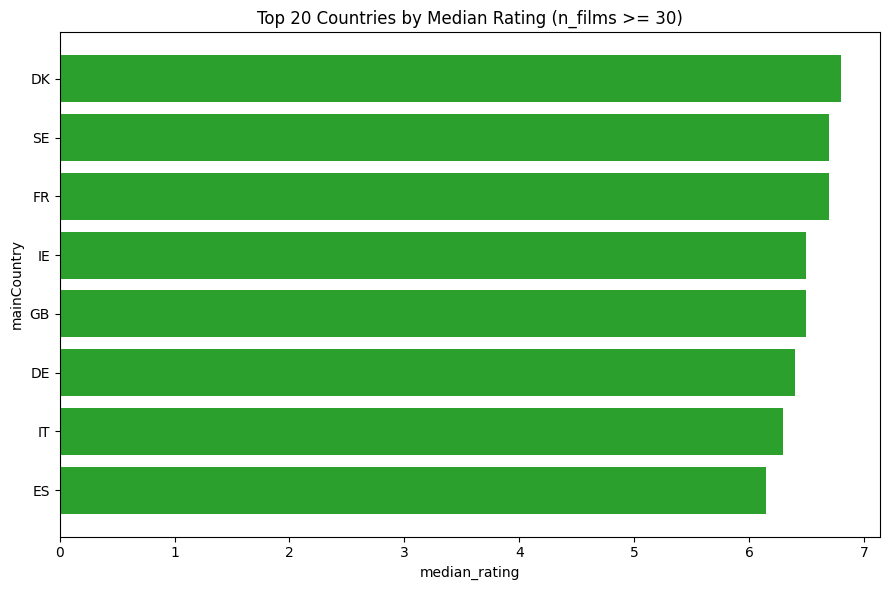

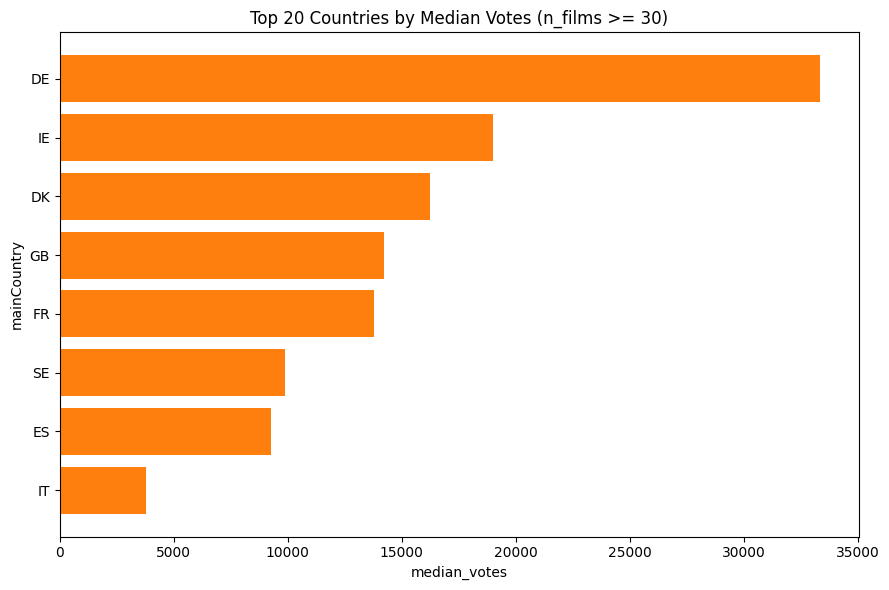

Saved figures to: /Users/andreas/Will-Agency-42576-From-analytics-to-action-/outputs/figures


In [8]:
import matplotlib.pyplot as plt
from pathlib import Path

if "mainCountry" in df.columns:
    min_n_films = 30
    out_dir = Path("outputs/figures")
    out_dir.mkdir(parents=True, exist_ok=True)

    work = pd.DataFrame({"mainCountry": df["mainCountry"]})
    work = work[work["mainCountry"].notna()].copy()

    if "imdbRating" in df.columns:
        work["imdbRating"] = pd.to_numeric(df.loc[work.index, "imdbRating"], errors="coerce")
    else:
        work["imdbRating"] = pd.NA

    if "numberOfVotes" in df.columns:
        work["numberOfVotes"] = pd.to_numeric(df.loc[work.index, "numberOfVotes"], errors="coerce")
    else:
        work["numberOfVotes"] = pd.NA

    country_stats = (
        work.groupby("mainCountry", dropna=False)
        .agg(
            n_films=("mainCountry", "size"),
            median_rating=("imdbRating", "median"),
            median_votes=("numberOfVotes", "median"),
            share_missing_rating=("imdbRating", lambda s: s.isna().mean()),
        )
        .reset_index()
        .sort_values("n_films", ascending=False)
    )

    print("country_stats (top 20 by n_films):")
    display(country_stats.head(20).reset_index(drop=True))

    quality_stats = country_stats[country_stats["n_films"] >= min_n_films].copy()
    print(f"Countries meeting threshold n_films >= {min_n_films}: {len(quality_stats)}")

    top_count = country_stats.head(20).sort_values("n_films", ascending=True)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top_count["mainCountry"], top_count["n_films"], color="#1f77b4")
    ax.set_title("Top 20 Countries by Film Count")
    ax.set_xlabel("n_films")
    ax.set_ylabel("mainCountry")
    fig.tight_layout()
    fig.savefig(out_dir / "country_top20_n_films.png", dpi=150)
    plt.show()
    plt.close(fig)

    rating_base = quality_stats.dropna(subset=["median_rating"]).sort_values("median_rating", ascending=False).head(20)
    if len(rating_base) > 0:
        top_rating = rating_base.sort_values("median_rating", ascending=True)
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(top_rating["mainCountry"], top_rating["median_rating"], color="#2ca02c")
        ax.set_title(f"Top 20 Countries by Median Rating (n_films >= {min_n_films})")
        ax.set_xlabel("median_rating")
        ax.set_ylabel("mainCountry")
        fig.tight_layout()
        fig.savefig(out_dir / "country_top20_median_rating_min30.png", dpi=150)
        plt.show()
        plt.close(fig)
    else:
        print("No countries available for median_rating plot after threshold/filtering.")

    votes_base = quality_stats.dropna(subset=["median_votes"]).sort_values("median_votes", ascending=False).head(20)
    if len(votes_base) > 0:
        top_votes = votes_base.sort_values("median_votes", ascending=True)
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(top_votes["mainCountry"], top_votes["median_votes"], color="#ff7f0e")
        ax.set_title(f"Top 20 Countries by Median Votes (n_films >= {min_n_films})")
        ax.set_xlabel("median_votes")
        ax.set_ylabel("mainCountry")
        fig.tight_layout()
        fig.savefig(out_dir / "country_top20_median_votes_min30.png", dpi=150)
        plt.show()
        plt.close(fig)
    else:
        print("No countries available for median_votes plot after threshold/filtering.")

    print(f"Saved figures to: {out_dir.resolve()}")
else:
    print("Country Analysis skipped: mainCountry column not found.")

## Genre Analysis

genre_stats (top 20 by n_films):


,genre,n_films,median_rating,median_runtime,median_votes
0,Drama,1188,6.80,106.0,13639.0
1,Thriller,628,6.30,101.0,18785.5
2,Comedy,530,6.40,97.0,13073.5
3,Romance,413,6.60,104.0,13220.0
4,Horror,405,5.80,93.0,7448.0
5,Adventure,333,6.30,101.0,20380.0
6,Crime,331,6.70,102.0,19543.0
7,Action,310,6.20,103.0,32859.5
8,Mystery,285,6.30,99.0,16494.0
9,Fantasy,221,6.30,98.0,18352.0


Genres meeting threshold n_films >= 50: 19


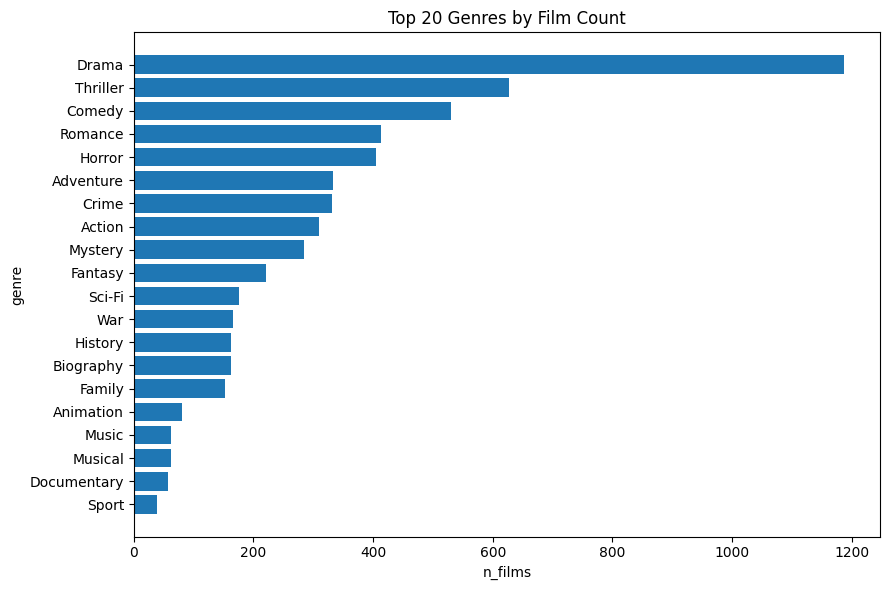

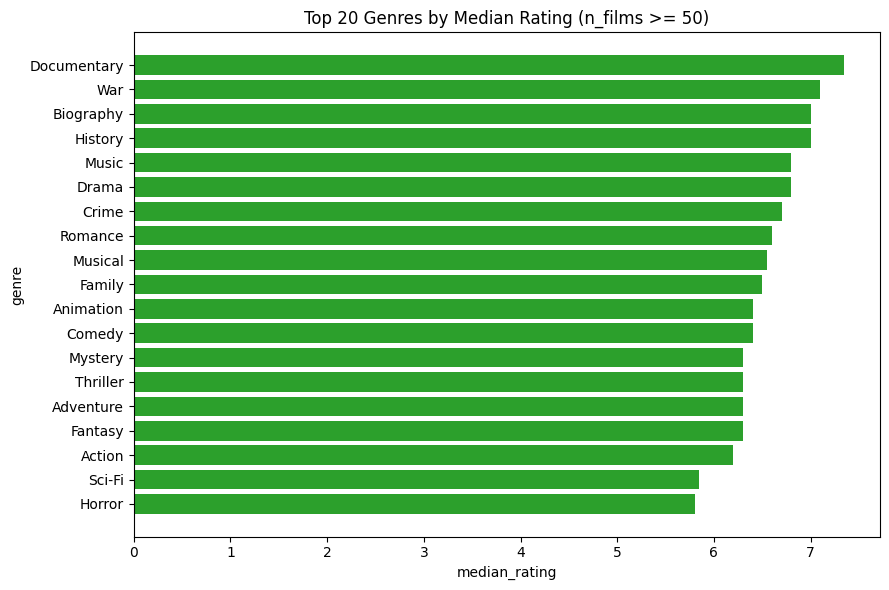

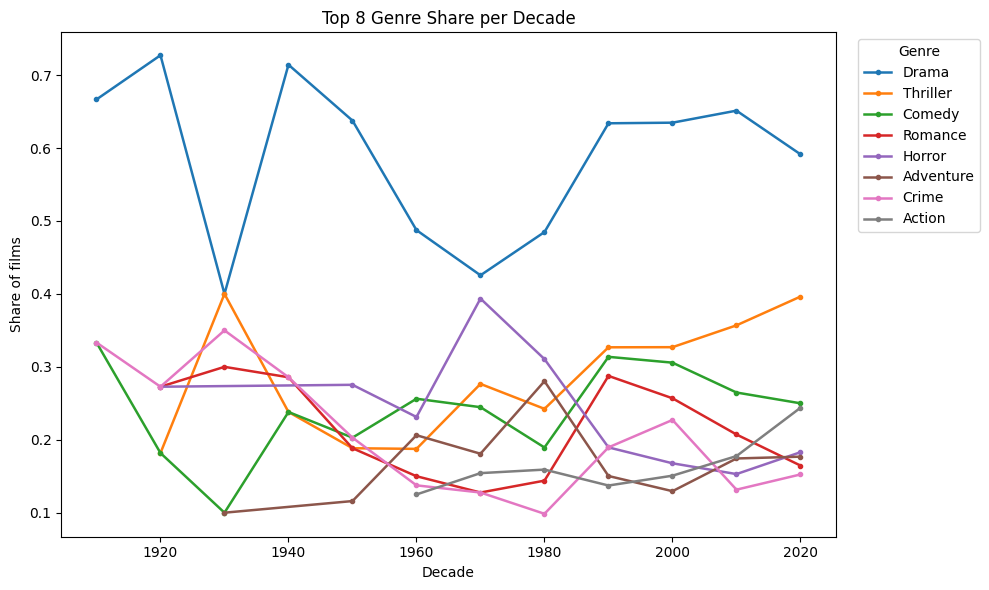

Saved figures to: /Users/andreas/Will-Agency-42576-From-analytics-to-action-/outputs/figures


In [9]:
import matplotlib.pyplot as plt
from pathlib import Path

if "genres" in df.columns:
    min_n_films = 50
    out_dir = Path("outputs/figures")
    out_dir.mkdir(parents=True, exist_ok=True)

    df["genres_list"] = df["genres"].fillna("").astype(str).apply(
        lambda x: [g.strip() for g in x.split(",") if g.strip()]
    )

    genre_df = df.explode("genres_list").rename(columns={"genres_list": "genre"})
    genre_df = genre_df[genre_df["genre"].notna() & (genre_df["genre"] != "")].copy()

    for col in ["imdbRating", "runtimeMinutes", "numberOfVotes", "releaseYear"]:
        if col in genre_df.columns:
            genre_df[col] = pd.to_numeric(genre_df[col], errors="coerce")

    genre_stats = (
        genre_df.groupby("genre", dropna=False)
        .agg(
            n_films=("genre", "size"),
            median_rating=("imdbRating", "median"),
            median_runtime=("runtimeMinutes", "median"),
            median_votes=("numberOfVotes", "median"),
        )
        .reset_index()
        .sort_values("n_films", ascending=False)
    )

    print("genre_stats (top 20 by n_films):")
    display(genre_stats.head(20).reset_index(drop=True))

    quality_genres = genre_stats[genre_stats["n_films"] >= min_n_films].copy()
    print(f"Genres meeting threshold n_films >= {min_n_films}: {len(quality_genres)}")

    top_count = genre_stats.head(20).sort_values("n_films", ascending=True)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top_count["genre"], top_count["n_films"], color="#1f77b4")
    ax.set_title("Top 20 Genres by Film Count")
    ax.set_xlabel("n_films")
    ax.set_ylabel("genre")
    fig.tight_layout()
    fig.savefig(out_dir / "genre_top20_n_films.png", dpi=150)
    plt.show()
    plt.close(fig)

    rating_base = quality_genres.dropna(subset=["median_rating"]).sort_values("median_rating", ascending=False).head(20)
    if len(rating_base) > 0:
        top_rating = rating_base.sort_values("median_rating", ascending=True)
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(top_rating["genre"], top_rating["median_rating"], color="#2ca02c")
        ax.set_title(f"Top 20 Genres by Median Rating (n_films >= {min_n_films})")
        ax.set_xlabel("median_rating")
        ax.set_ylabel("genre")
        fig.tight_layout()
        fig.savefig(out_dir / "genre_top20_median_rating_min50.png", dpi=150)
        plt.show()
        plt.close(fig)
    else:
        print("No genres available for median_rating plot after threshold/filtering.")

    if "releaseYear" in genre_df.columns:
        top8_genres = genre_stats.head(8)["genre"].tolist()
        trend_df = genre_df[genre_df["genre"].isin(top8_genres)].copy()
        trend_df = trend_df[trend_df["releaseYear"].notna()].copy()

        if len(trend_df) > 0:
            trend_df["decade"] = (trend_df["releaseYear"].round().astype(int) // 10) * 10

            decade_totals = pd.to_numeric(df["releaseYear"], errors="coerce").dropna().round().astype(int)
            decade_totals = ((decade_totals // 10) * 10).value_counts().sort_index()
            decade_totals = decade_totals.rename("total_films").rename_axis("decade").reset_index()

            trend = (
                trend_df.groupby(["decade", "genre"]).size().rename("n_films_genre").reset_index()
                .merge(decade_totals, on="decade", how="left")
            )
            trend["share"] = trend["n_films_genre"] / trend["total_films"]

            fig, ax = plt.subplots(figsize=(10, 6))
            for g in top8_genres:
                s = trend[trend["genre"] == g].sort_values("decade")
                if len(s) > 0:
                    ax.plot(s["decade"], s["share"], marker="o", linewidth=1.8, markersize=3, label=g)
            ax.set_title("Top 8 Genre Share per Decade")
            ax.set_xlabel("Decade")
            ax.set_ylabel("Share of films")
            ax.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
            fig.tight_layout()
            fig.savefig(out_dir / "genre_top8_share_per_decade.png", dpi=150)
            plt.show()
            plt.close(fig)
        else:
            print("No data available for genre share trend by decade.")
    else:
        print("Genre trend skipped: releaseYear column not found.")

    print(f"Saved figures to: {out_dir.resolve()}")
else:
    print("Genre Analysis skipped: genres column not found.")

## Scope Sanity Check

In [10]:
if "mainCountry" in df.columns:
    main_country = df["mainCountry"].astype("string").str.strip()
    missing_main = main_country.isna() | (main_country == "")
    valid_main = main_country[~missing_main]

    print(f"Unique countries in mainCountry: {valid_main.nunique()}")

    country_counts = valid_main.value_counts()
    top_30_countries = country_counts.head(30).rename_axis("mainCountry").reset_index(name="n_films")
    bottom_30_countries = country_counts.sort_values(ascending=True).head(30).rename_axis("mainCountry").reset_index(name="n_films")

    print("Top 30 countries by film count:")
    display(top_30_countries)

    print("Bottom 30 countries by film count:")
    display(bottom_30_countries)

    missing_rating = pd.Series(False, index=df.index)
    if "imdbRating" in df.columns:
        missing_rating = pd.to_numeric(df["imdbRating"], errors="coerce").isna()

    missing_votes = pd.Series(False, index=df.index)
    if "numberOfVotes" in df.columns:
        missing_votes = pd.to_numeric(df["numberOfVotes"], errors="coerce").isna()

    missing_tbl = pd.DataFrame({
        "missing_mainCountry": missing_main,
        "missing_rating": missing_rating,
        "missing_votes": missing_votes,
    })
    missing_tbl["missing_rating_or_votes"] = missing_tbl["missing_rating"] | missing_tbl["missing_votes"]

    missing_corr = (
        missing_tbl.groupby("missing_mainCountry")
        .agg(
            rows=("missing_mainCountry", "size"),
            missing_rating_rows=("missing_rating", "sum"),
            missing_votes_rows=("missing_votes", "sum"),
            missing_rating_or_votes_rows=("missing_rating_or_votes", "sum"),
        )
        .reset_index()
    )
    for col in ["missing_rating_rows", "missing_votes_rows", "missing_rating_or_votes_rows"]:
        missing_corr[col.replace("_rows", "_pct")] = (missing_corr[col] / missing_corr["rows"] * 100).round(2)

    print("Missing mainCountry vs missing rating/votes:")
    display(missing_corr)

    if "allCountries" in df.columns:
        all_countries_first = (
            df["allCountries"]
            .astype("string")
            .fillna("")
            .str.split(",")
            .str[0]
            .str.strip()
        )
        comparable = (~missing_main) & (all_countries_first != "")

        comp_df = df.loc[comparable].copy()
        comp_df["mainCountry_norm"] = main_country.loc[comparable].values
        comp_df["allCountries_first"] = all_countries_first.loc[comparable].values
        comp_df["is_match"] = comp_df["mainCountry_norm"] == comp_df["allCountries_first"]

        consistency_summary = pd.DataFrame({
            "comparable_rows": [len(comp_df)],
            "matches": [int(comp_df["is_match"].sum())],
            "mismatches": [int((~comp_df["is_match"]).sum())],
        })
        consistency_summary["match_rate_pct"] = (
            consistency_summary["matches"] / consistency_summary["comparable_rows"] * 100
        ).round(2)

        print("mainCountry vs first token of allCountries (where comparable):")
        display(consistency_summary)

        mismatch_rows = comp_df[~comp_df["is_match"]].copy()
        mismatch_cols = [
            col
            for col in ["titleId", "originalTitle", "mainCountry_norm", "allCountries", "allCountries_first"]
            if col in mismatch_rows.columns
        ]
        print("First 20 mismatches (if any):")
        display(mismatch_rows[mismatch_cols].head(20).reset_index(drop=True))
else:
    print("Scope Sanity Check skipped: mainCountry column not found.")

Unique countries in mainCountry: 29
Top 30 countries by film count:


,mainCountry,n_films
0,GB,981
1,FR,265
2,IT,167
3,DE,163
4,ES,92
5,IE,65
6,SE,36
7,DK,34
8,GR,22
9,CZ,21


Bottom 30 countries by film count:


,mainCountry,n_films
0,LT,1
1,LU,1
2,PT,2
3,UA,2
4,SK,2
5,EE,2
6,LV,4
7,IS,4
8,BG,4
9,RO,6


Missing mainCountry vs missing rating/votes:


,missing_mainCountry,rows,missing_rating_rows,missing_votes_rows,missing_rating_or_votes_rows,missing_rating_pct,missing_votes_pct,missing_rating_or_votes_pct
0,False,2000,0,0,0,0.0,0.0,0.0


mainCountry vs first token of allCountries (where comparable):


,comparable_rows,matches,mismatches,match_rate_pct
0,2000,2000,0,100.0


First 20 mismatches (if any):


,titleId,originalTitle,mainCountry_norm,allCountries,allCountries_first


## Outliers & Edge Cases

In [11]:
show_cols = [
    "titleId",
    "originalTitle",
    "releaseYear",
    "runtimeMinutes",
    "imdbRating",
    "numberOfVotes",
    "mainCountry",
    "genres",
]
show_cols = [c for c in show_cols if c in df.columns]
rename_cols = {"runtimeMinutes": "runtime", "numberOfVotes": "votes"}

edge_df = df.copy()
for c in ["releaseYear", "runtimeMinutes", "imdbRating", "numberOfVotes"]:
    if c in edge_df.columns:
        edge_df[c] = pd.to_numeric(edge_df[c], errors="coerce")

if "runtimeMinutes" in edge_df.columns:
    top_runtime = (
        edge_df.sort_values("runtimeMinutes", ascending=False)[show_cols]
        .head(15)
        .rename(columns=rename_cols)
        .reset_index(drop=True)
    )
    print("Top 15 by runtimeMinutes:")
    display(top_runtime)
else:
    print("runtimeMinutes column not found.")

if "numberOfVotes" in edge_df.columns:
    top_votes = (
        edge_df.sort_values("numberOfVotes", ascending=False)[show_cols]
        .head(15)
        .rename(columns=rename_cols)
        .reset_index(drop=True)
    )
    print("Top 15 by numberOfVotes:")
    display(top_votes)
else:
    print("numberOfVotes column not found.")

if "imdbRating" in edge_df.columns:
    min_votes_for_rating = 1000
    rating_df = edge_df.copy()
    sort_cols = ["imdbRating"]
    sort_asc = [False]

    if "numberOfVotes" in edge_df.columns:
        rating_df = rating_df[rating_df["numberOfVotes"] >= min_votes_for_rating]
        sort_cols = ["imdbRating", "numberOfVotes"]
        sort_asc = [False, False]
        print(f"Top 15 by imdbRating (votes >= {min_votes_for_rating}):")
    else:
        print("Top 15 by imdbRating:")

    top_rating = (
        rating_df.sort_values(sort_cols, ascending=sort_asc)[show_cols]
        .head(15)
        .rename(columns=rename_cols)
        .reset_index(drop=True)
    )
    display(top_rating)
else:
    print("imdbRating column not found.")

Top 15 by runtimeMinutes:


,titleId,originalTitle,releaseYear,runtime,imdbRating,votes,mainCountry,genres
0,tt0074084,Novecento,1976.0,317.0,7.6,27847.0,IT,"Drama, History"
1,tt0108167,Smoking/No Smoking,1993.0,298.0,7.4,1962.0,FR,"Comedy, Drama"
2,tt0383974,Le chagrin et la pitié,1969.0,251.0,8.1,4169.0,CH,"Documentary, History, War"
3,tt0066904,Le chagrin et la pitié,1969.0,251.0,8.1,4203.0,CH,"Documentary, History, War"
4,tt0056172,Lawrence of Arabia,1962.0,227.0,8.3,323660.0,GB,"Adventure, Biography, Drama, War"
5,tt0083987,Gandhi,1982.0,191.0,8.0,242246.0,GB,"Biography, Drama, History"
6,tt0083922,Fanny och Alexander,1982.0,188.0,8.1,68509.0,SE,Drama
7,tt0460829,Inland Empire,2006.0,180.0,6.8,63975.0,FR,"Drama, Fantasy, Mystery, Thriller"
8,tt1646958,Autobiografia lui Nicolae Ceausescu,2010.0,180.0,7.5,1657.0,RO,"Documentary, Biography, History"
9,tt0060196,"Il buono, il brutto, il cattivo",1966.0,178.0,8.8,835509.0,IT,"Adventure, Drama, Western"


Top 15 by numberOfVotes:


,titleId,originalTitle,releaseYear,runtime,imdbRating,votes,mainCountry,genres
0,tt0137523,Fight Club,1999.0,139.0,8.8,2407126.0,DE,Drama
1,tt0110413,Léon,1994.0,110.0,8.5,1280541.0,FR,"Action, Crime, Drama, Thriller"
2,tt0081505,The Shining,1980.0,146.0,8.4,1144494.0,GB,"Drama, Horror"
3,tt1201607,Harry Potter and the Deathly Hallows - Part 2,2011.0,130.0,8.1,976358.0,GB,"Adventure, Family, Fantasy, Mystery"
4,tt1675434,Intouchables,2011.0,112.0,8.5,957603.0,FR,"Comedy, Drama"
5,tt0253474,The Pianist,2002.0,150.0,8.5,945171.0,FR,"Biography, Drama, Music, War"
6,tt0066921,A Clockwork Orange,1971.0,136.0,8.2,899582.0,GB,"Crime, Sci-Fi"
7,tt0241527,Harry Potter and the Sorcerer's Stone,2001.0,152.0,7.7,884416.0,GB,"Adventure, Family, Fantasy"
8,tt0060196,"Il buono, il brutto, il cattivo",1966.0,178.0,8.8,835509.0,IT,"Adventure, Drama, Western"
9,tt1205489,Gran Torino,2008.0,116.0,8.1,829091.0,DE,Drama


Top 15 by imdbRating (votes >= 1000):


,titleId,originalTitle,releaseYear,runtime,imdbRating,votes,mainCountry,genres
0,tt0137523,Fight Club,1999.0,139.0,8.8,2407126.0,DE,Drama
1,tt0060196,"Il buono, il brutto, il cattivo",1966.0,178.0,8.8,835509.0,IT,"Adventure, Drama, Western"
2,tt0122786,La vita è bella,1997.0,116.0,8.6,754680.0,IT,"Comedy, Drama, Romance, War"
3,tt0110413,Léon,1994.0,110.0,8.5,1280541.0,FR,"Action, Crime, Drama, Thriller"
4,tt1675434,Intouchables,2011.0,112.0,8.5,957603.0,FR,"Comedy, Drama"
5,tt0253474,The Pianist,2002.0,150.0,8.5,945171.0,FR,"Biography, Drama, Music, War"
6,tt0064116,C'era una volta il West,1968.0,166.0,8.5,360357.0,IT,"Drama, Western"
7,tt0095765,Nuovo Cinema Paradiso,1988.0,174.0,8.5,293926.0,IT,"Drama, Romance"
8,tt1424432,Senna,2010.0,106.0,8.5,79059.0,GB,"Documentary, Biography, Sport"
9,tt0081505,The Shining,1980.0,146.0,8.4,1144494.0,GB,"Drama, Horror"


- Runtime has a long right tail: the max is **317 minutes** while the 99th percentile is about **164 minutes**, so a small number of very long films dominate the extreme end.
- The title **"Le chagrin et la pitié"** appears twice in the runtime top list with different `titleId` values but very similar metadata, which looks like a possible duplicate/alternate-record case.
- Vote counts are highly concentrated at the top: **Fight Club** has about **2.4M votes**, which is well above the rest and more than 3x the approximate 99th percentile (~738k).
- With the `votes >= 1000` filter, the top-rated entries are still supported by substantial vote counts (in this dataset, the top-15 minimum is around **79k votes**), so they are not tiny-sample artifacts.
- Some `mainCountry` tags in outlier rows may reflect production metadata rather than intuitive story setting or language origin (for example, highly familiar English-language titles can map to non-GB/US codes in this table).

## Key Takeaways (Initial EDA)

### Findings
- Ratings are concentrated in a relatively narrow band around mid/high values, with a center near the mid-6s (`hist_imdbRating.png`).
- Runtime is centered around standard feature length (~90–115 minutes) with a long right tail of very long films (`hist_runtimeMinutes.png`).
- Vote counts are strongly right-skewed, with a small set of titles receiving very large attention (`hist_numberOfVotes.png`).
- The log transform makes vote spread much more interpretable and confirms strong scale compression at the high end (`hist_log10_numberOfVotes_plus1.png`).
- Film volume is concentrated in recent decades, with visible growth into the 2000s/2010s in this sample (`films_per_decade.png`).
- Rating vs votes shows broad dispersion rather than a tight linear pattern, even after log-scaling votes (`scatter_imdbRating_vs_log_votes.png`).
- Rating vs runtime also appears diffuse, with no strong monotonic relationship in the cloud (`scatter_imdbRating_vs_runtimeMinutes.png`).
- Median ratings by decade move within a fairly tight range, suggesting modest temporal variation rather than dramatic swings (`median_imdbRating_by_decade.png`).
- Median log-votes by decade shift over time, indicating changing visibility/engagement patterns across release periods (`median_log_votes_by_decade.png`).
- The country and genre distributions are concentrated: a few countries/genres account for much of the sample (`country_top20_n_films.png`, `genre_top20_n_films.png`).

### Limitations & Bias
- IMDb votes are not a random sample of viewers; participation is self-selected and platform-specific.
- Vote volume can reflect popularity, franchise effects, and recency exposure, not just perceived quality.
- Language accessibility and subtitle availability can bias who watches and rates a title.
- `mainCountry` may simplify multi-country productions and obscure co-production structure.
- Genre tags are multi-label and editorial; splitting by comma can blur subgenre nuance.
- Older titles that remain in the dataset can reflect survivorship and canon effects.
- Metadata quality (alternate cuts, duplicate-like entries, changing tags) can affect tail analyses.
- Ratings and votes are observational outcomes; these patterns are descriptive and not causal.

### Next Questions
- How do rating and vote patterns change when restricting to a fixed release window (for example, 2000+ only)?
- Do country comparisons remain similar after adjusting for genre mix and decade mix?
- Which genres show the largest decade-to-decade share changes, and are shifts concentrated in a few countries?
- What changes when we require stronger vote thresholds (for example, >=10k) for ranking analyses?
- Are there systematic differences between single-country and multi-country titles (using `allCountries`)?
- Which potential duplicate or alternate-version records should be consolidated before deeper modeling?

### NOTE: Further Work
- This can be enriched by joining external film datasets (for example TMDb, Box Office Mojo, The Numbers, awards/critic scores, and release-scale metadata) to add budget, revenue/tickets, marketing proxies, and platform context.
- Correlations worth deeper testing: `log_votes` vs `imdbRating`, runtime vs rating, country/genre composition vs vote volume, and decade effects; use both Pearson and Spearman, and stratify by decade/genre to reduce confounding.
- Predicting box office tickets is feasible only after adding a ticket/revenue target; then use this dataset as feature input (rating, votes, runtime, year, genre mix, country) plus external predictors like budget, franchise status, cast/director prior performance, and release timing.
- Keep this as a predictive exercise, not a causal claim: evaluate with temporal train/test splits and report uncertainty/error bands.